## Robustness on CIFAR-10-C (common corruptions)

This notebook evaluates models trained on CIFAR-10 on **CIFAR-10-C** (corruptions that mimic common degradations) and reports **per-severity accuracy (1–5)** and means.


In [ ]:
from pathlib import Path


def project_root() -> Path:
    """Resolve repo root (repo root, notebooks/, or other subfolders)."""
    cwd = Path.cwd().resolve()
    for d in [cwd, *cwd.parents]:
        km = d / "keras_models"
        if km.is_dir() and any(km.glob("*.keras")):
            return d
        if (d / ".git").exists() and (d / "results").is_dir():
            return d
    if (cwd / "datasets").is_dir() or (cwd / "results").is_dir():
        return cwd
    if (cwd.parent / "datasets").is_dir() or (cwd.parent / "results").is_dir():
        return cwd.parent
    return cwd


ROOT = project_root()


In [1]:
from __future__ import annotations

import os
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import tensorflow as tf

# (dica) Se der NameError por variables, rode esta cell primeiro.


In [2]:

# Pasta onde o CIFAR-10-C will be cached
DATA_DIR = ROOT / "datasets"
CIFAR10C_DIR = DATA_DIR / "cifar10c"
CIFAR10C_DIR.mkdir(parents=True, exist_ok=True)

# URL oficial (Hendrycks & Dietterich) via Zenodo
CIFAR10C_TAR_URL = "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar?download=1"
CIFAR10C_TAR_PATH = CIFAR10C_DIR / "CIFAR-10-C.tar"


def download_file(url: str, out_path: Path, chunk_size: int = 1024 * 1024) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    if out_path.exists() and out_path.stat().st_size > 0:
        print(f"OK (já existe): {out_path} ({out_path.stat().st_size/1e6:.1f} MB)")
        return

    print("Baixando (pode demorar; arquivo grande):", url)
    tmp_path = out_path.with_suffix(out_path.suffix + ".part")
    if tmp_path.exists():
        tmp_path.unlink()

    with urllib.request.urlopen(url) as r, open(tmp_path, "wb") as f:
        total_hdr = r.headers.get("Content-Length")
        total = int(total_hdr) if total_hdr and total_hdr.isdigit() else None

        downloaded = 0
        next_report = 0
        report_step = 50 * 1024 * 1024  # 50 MB

        while True:
            chunk = r.read(chunk_size)
            if not chunk:
                break
            f.write(chunk)
            downloaded += len(chunk)

            if downloaded >= next_report:
                next_report = downloaded + report_step
                if total:
                    pct = 100.0 * downloaded / total
                    print(f"  {pct:6.2f}% ({downloaded/1e6:.1f}/{total/1e6:.1f} MB)")
                else:
                    print(f"  {downloaded/1e6:.1f} MB")

    tmp_path.replace(out_path)
    print("Download complete:", out_path)


def extract_tar(tar_path: Path, out_dir: Path) -> None:
    # O tar contém uma pasta chamada CIFAR-10-C/ com os .npy.
    marker = out_dir / "CIFAR-10-C" / "labels.npy"
    if marker.exists():
        print("OK (already extracted):", marker)
        return

    print("Extraindo:", tar_path)
    with tarfile.open(tar_path, "r") as tar:
        # Python 3.12+ recomenda usar um filtro para extração mais segura.
        try:
            tar.extractall(path=out_dir, filter="data")
        except TypeError:
            # Compatibilidade com versões antigas do Python.
            tar.extractall(path=out_dir)

    print("Extração concluída em:", out_dir)


download_file(CIFAR10C_TAR_URL, CIFAR10C_TAR_PATH)
extract_tar(CIFAR10C_TAR_PATH, CIFAR10C_DIR)


OK (já existe): datasets\cifar10c\CIFAR-10-C.tar (2918.5 MB)
OK (already extracted): datasets\cifar10c\CIFAR-10-C\labels.npy


In [3]:
# Localiza a raiz do CIFAR-10-C (onde ficam labels.npy e os arquivos *.npy de corruption)

# Define o directory base mesmo se você já tiver instalado (evita NameError fora de ordem)
DATA_DIR = ROOT / "datasets"
CIFAR10C_DIR = DATA_DIR / "cifar10c"

def find_cifar10c_root(base_dir: Path) -> Path:
    # Procura labels.npy recursivamente e usa o directory pai.
    hits = list(base_dir.rglob("labels.npy"))
    if not hits:
        raise FileNotFoundError(f"Could not find labels.npy in {base_dir.resolve()}")
    return hits[0].parent


CIFAR10C_ROOT = find_cifar10c_root(CIFAR10C_DIR)
print("CIFAR-10-C root:", CIFAR10C_ROOT.resolve())

labels_path = CIFAR10C_ROOT / "labels.npy"
y_c = np.load(labels_path).astype("int64")
print("labels:", y_c.shape, y_c.dtype, "classes:", np.unique(y_c).size)

# Corruption files (each with shape (50000, 32, 32, 3))
corruption_files = sorted([p for p in CIFAR10C_ROOT.glob("*.npy") if p.name != "labels.npy"])
corruptions = [p.stem for p in corruption_files]
print("num corruptions:", len(corruptions))
print("primeiras 10:", corruptions[:10])

# CIFAR-10-C convention: 5 severities, 10k images each
SEVERITIES = [1, 2, 3, 4, 5]
N_PER_SEVERITY = 10_000


CIFAR-10-C root: C:/home/anonymous/project/Lightweight Analyses/project/Lightweight Analyses\project\Lightweight Analyses\datasets\cifar10c\CIFAR-10-C
labels: (50000,) int64 classes: 10
num corruptions: 19
primeiras 10: ['brightness', 'contrast', 'defocus_blur', 'elastic_transform', 'fog', 'frost', 'gaussian_blur', 'gaussian_noise', 'glass_blur', 'impulse_noise']


In [9]:
# Load UM OU MAIS models Keras (.keras) do seu projeto.
# Vamos usar como baseline o model com PIOR accuracy no clean CIFAR-10.

MODELS = [
    ("MobileNetV3Small", Path("keras_models/MobileNetV3Small_CIFAR10.keras")),
    ("EfficientNetB0", Path("keras_models/EfficientNetB0_CIFAR10.keras")),
    ("MCUNet", Path("keras_models/MCUNet_CIFAR10.keras")),
]

# Você pode comentar/remover models que não existam.


def load_models(specs):
    out = []
    for name, path in specs:
        m = tf.keras.models.load_model(path)
        m.trainable = False
        out.append((name, path, m))
        print("OK:", name, "<-", path)
    return out


models = load_models(MODELS)

# Inferimos IMG_SIZE do 1º model (assumimos que todos usam o mesmo input size)
IMG_SIZE = int(models[0][2].input_shape[1])
BATCH_SIZE = 128

print("IMG_SIZE:", IMG_SIZE)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]


OK: MobileNetV3Small <- keras_models\MobileNetV3Small_CIFAR10.keras
OK: EfficientNetB0 <- keras_models\EfficientNetB0_CIFAR10.keras
OK: MCUNet <- keras_models\MCUNet_CIFAR10.keras
IMG_SIZE: 160


In [10]:
AUTOTUNE = tf.data.AUTOTUNE


def preprocess_image_for_model(image, label):
    # CIFAR-10-C vem em uint8 [0,255]
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE), method="bilinear")
    return image, label


def make_ds(x: np.ndarray, y: np.ndarray, batch_size: int = BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.map(preprocess_image_for_model, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


def accuracy_on_ds(model: tf.keras.Model, ds: tf.data.Dataset) -> float:
    correct = 0
    total = 0
    for xb, yb in ds:
        logits = model(xb, training=False)
        pred = tf.argmax(logits, axis=-1, output_type=yb.dtype)
        correct += int(tf.reduce_sum(tf.cast(pred == yb, tf.int32)).numpy())
        total += int(yb.shape[0])
    return correct / max(total, 1)


In [11]:
def load_corruption(corruption: str) -> np.ndarray:
    path = CIFAR10C_ROOT / f"{corruption}.npy"
    if not path.exists():
        raise FileNotFoundError(f"Could not find {path}")
    x = np.load(path)  # (50000, 32, 32, 3)
    if x.ndim != 4 or x.shape[1:4] != (32, 32, 3):
        raise ValueError(f"Shape inesperado em {path.name}: {x.shape}")
    return x


def eval_corruption_acc(model: tf.keras.Model, corruption: str, severities=None) -> dict:
    """Retorna accuracies por severidade e mean 1–5."""
    if severities is None:
        severities = globals().get("SEVERITIES", [1, 2, 3, 4, 5])
    n_per = int(globals().get("N_PER_SEVERITY", 10_000))

    x = load_corruption(corruption)
    out = {"corruption": corruption}

    for s in severities:
        start = (s - 1) * n_per
        end = s * n_per
        x_s = x[start:end]
        y_s = y_c[start:end]

        ds = make_ds(x_s, y_s)
        out[f"acc_s{s}"] = accuracy_on_ds(model, ds)

    out["acc_mean_1_5"] = float(np.mean([out[f"acc_s{s}"] for s in severities]))
    return out


def err_from_acc(acc: float) -> float:
    return 1.0 - float(acc)


# Avalia no clean CIFAR-10 para TODOS os models e escolhe baseline = pior clean acc
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

y_test = y_test.squeeze().astype("int64")
clean_ds = make_ds(x_test, y_test)

clean = []
for name, path, m in models:
    acc = accuracy_on_ds(m, clean_ds)
    clean.append({"name": name, "path": str(path), "clean_acc": float(acc), "clean_err": err_from_acc(acc)})
    print(f"{name:16s} clean_acc={acc:.4f} clean_err={err_from_acc(acc):.4f}")

baseline = max(clean, key=lambda d: d["clean_err"])  # worst on clean
BASELINE_NAME = baseline["name"]
print("\nBaseline (worst on clean):", BASELINE_NAME, "| clean_acc=%.4f" % baseline["clean_acc"])


MobileNetV3Small clean_acc=0.9044 clean_err=0.0956
EfficientNetB0   clean_acc=0.9461 clean_err=0.0539
MCUNet           clean_acc=0.8602 clean_err=0.1398

Baseline (worst on clean): MCUNet | clean_acc=0.8602


In [ ]:
# Evaluation por CE (Corruption Error) com persistence em JSON/JSONL
# CE(model, corr, s) = err_model(corr, s) / err_baseline(corr, s)
# Baseline = model with worst clean accuracy (from previous cell).

import json
import os
from pathlib import Path

# -------------------------
# Configuração
# -------------------------
# Escolha quais corruptions avaliar (use EVAL_ALL_CORRUPTIONS=True para avaliar todas)
SELECTED = [
    "gaussian_noise",
    "shot_noise",
    "motion_blur",
    "defocus_blur",
    "brightness",
    "fog",
    "contrast",
    "jpeg_compression",
]
EVAL_ALL_CORRUPTIONS = True
if EVAL_ALL_CORRUPTIONS:
    SELECTED = corruptions

# Persistência (salva a cada item; ideal pra evitar perda em reboot)
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_TAG = f"cifar10c_baseline-{BASELINE_NAME}".replace(" ", "_")
BASELINE_ACC_PATH = RESULTS_DIR / f"{RUN_TAG}_baseline_acc.json"
CE_RESULTS_JSONL_PATH = RESULTS_DIR / f"{RUN_TAG}_ce_results.jsonl"
FORCE_RECOMPUTE = False
FSYNC_EACH_WRITE = True


def _load_json(path: Path, default):
    if not path.exists():
        return default
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return default


def _atomic_write_json(path: Path, obj) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")
    os.replace(tmp, path)


def _load_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except Exception:
            # ignora linhas corrompidas/incompletas
            pass
    return rows


def _append_jsonl(path: Path, row: dict) -> None:
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")
        f.flush()
        if FSYNC_EACH_WRITE:
            os.fsync(f.fileno())


# -------------------------
# Baseline (com cache)
# -------------------------
baseline_model = None
for name, path, m in models:
    if name == BASELINE_NAME:
        baseline_model = m
        break
if baseline_model is None:
    raise RuntimeError(f"Could not find baseline model: {BASELINE_NAME}")

# Load saved baseline_acc if any; only compute what is missing
baseline_acc = _load_json(BASELINE_ACC_PATH, {})

for c in SELECTED:
    if (not FORCE_RECOMPUTE) and (c in baseline_acc):
        # show previously stored values
        try:
            print(f"[baseline/cached] {c:20s} mean_acc={baseline_acc[c]['acc_mean_1_5']:.4f}")
        except Exception:
            print(f"[baseline/cached] {c:20s} (sem acc_mean_1_5)")
        continue

    baseline_acc[c] = eval_corruption_acc(baseline_model, c)
    _atomic_write_json(BASELINE_ACC_PATH, baseline_acc)
    print(f"[baseline] {c:20s} mean_acc={baseline_acc[c]['acc_mean_1_5']:.4f}")


def ce_from_acc(acc_model: float, acc_base: float) -> float:
    eb = err_from_acc(acc_base)
    if eb <= 0:
        return float("nan")
    return err_from_acc(acc_model) / eb


# -------------------------
# CE by model/corruption (resumed from JSONL)
# -------------------------
ce_results = _load_jsonl(CE_RESULTS_JSONL_PATH)
latest_by_key = {}
for r in ce_results:
    if isinstance(r, dict) and "model" in r and "corruption" in r:
        latest_by_key[(r["model"], r["corruption"])] = r

done = set(latest_by_key.keys())

for name, path, m in models:
    for c in SELECTED:
        key = (name, c)
        if (not FORCE_RECOMPUTE) and (key in done):
            continue

        acc = eval_corruption_acc(m, c)
        base = baseline_acc[c]

        row = {"model": name, "corruption": c}

        # CE_s = err_model(s) / err_baseline(s)
        # Agregado (Hendrycks & Dietterich): CE = (Σ_s err_model(s)) / (Σ_s err_baseline(s))
        num_err = 0.0
        den_err = 0.0

        for s in SEVERITIES:
            acc_ms = float(acc[f"acc_s{s}"])
            acc_bs = float(base[f"acc_s{s}"])

            row[f"acc_s{s}"] = acc_ms
            row[f"ce_s{s}"] = ce_from_acc(acc_ms, acc_bs)

            num_err += err_from_acc(acc_ms)
            den_err += err_from_acc(acc_bs)

        row["acc_mean_1_5"] = float(acc["acc_mean_1_5"])

        # Keep legacy metric (mean of ratios) for reference/debug
        row["ce_mean_of_ratios_1_5"] = float(np.nanmean([row[f"ce_s{s}"] for s in SEVERITIES]))

        # Main metric (matches the paper): ratio of sums
        row["ce_mean_1_5"] = float(num_err / den_err) if den_err > 0 else float("nan")

        latest_by_key[key] = row
        done.add(key)
        _append_jsonl(CE_RESULTS_JSONL_PATH, row)

ce_results = list(latest_by_key.values())

# Resumo por model (mCE)
# CE(c) = (Σ_s err_model(c,s)) / (Σ_s err_baseline(c,s))
# mCE = mean do CE(c) sobre corruptions
print("\n=== mCE por model (CE=Σ_s err/Σ_s err_baseline; mean sobre corruptions) ===")
for name, _, _ in models:
    rows = [r for r in ce_results if r["model"] == name and r["corruption"] in SELECTED]
    mce = float(np.nanmean([r["ce_mean_1_5"] for r in rows]))
    print(f"{name:16s} mCE={mce:.4f}" + (" (baseline)" if name == BASELINE_NAME else ""))

# Detalhe: pior -> melhor por CE (quanto MENOR melhor; baseline tende a ~1.0)
print("\n=== Pior->melhor por corruption (CE=Σerr/Σerr_baseline) ===")
for c in SELECTED:
    rows = [r for r in ce_results if r["corruption"] == c]
    rows = sorted(rows, key=lambda d: d["ce_mean_1_5"], reverse=True)
    top = " | ".join([f"{r['model']}={r['ce_mean_1_5']:.3f}" for r in rows])
    print(f"{c:20s} {top}")


[baseline] brightness           mean_acc=0.8382
[baseline] contrast             mean_acc=0.6253
[baseline] defocus_blur         mean_acc=0.7350
[baseline] elastic_transform    mean_acc=0.7386
[baseline] fog                  mean_acc=0.7649
[baseline] frost                mean_acc=0.7007
[baseline] gaussian_blur        mean_acc=0.6684
[baseline] gaussian_noise       mean_acc=0.5112
[baseline] glass_blur           mean_acc=0.5011
[baseline] impulse_noise        mean_acc=0.5781
[baseline] jpeg_compression     mean_acc=0.7765
[baseline] motion_blur          mean_acc=0.6753
[baseline] pixelate             mean_acc=0.7294
[baseline] saturate             mean_acc=0.8326
[baseline] shot_noise           mean_acc=0.5990
[baseline] snow                 mean_acc=0.7153
[baseline] spatter              mean_acc=0.7739
[baseline] speckle_noise        mean_acc=0.6189
[baseline] zoom_blur            mean_acc=0.6716

=== CE médio por model (avg over severities, then over corruptions) ===
MobileNetV3Smal

## MCUNet (official) — CIFAR-10-C robustness

Standalone: only needs CIFAR-10-C downloaded (cells 1–4) and the model `MCUNet_Official_CIFAR10.keras` exista.
Os results dos outros models **não são recalculados** — são lidos do JSONL existente.
Os novos results são **acrescentados** ao mesmo JSONL para que as cells de visualização já existentes incluam o MCUNet Oficial.

In [1]:
# =====================================================================
# MCUNet (official) — CIFAR-10-C robustness
# (cell standalone: só precisa que o CIFAR-10-C esteja downloaded)
# =====================================================================
import json, os, sys
import numpy as np
import tensorflow as tf
from pathlib import Path

# --- Registrar ImageNetNormalization (necessário para carregar o .keras) ---
_register = getattr(tf.keras.utils, 'register_keras_serializable', None) or \
            getattr(tf.keras.saving, 'register_keras_serializable', None)

@_register(package="MCUNet")
class ImageNetNormalization(tf.keras.layers.Layer):
    """ImageNet normalization: (x/255 - mean) / std"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
        self.std  = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)
    def call(self, x):
        return (x / 255.0 - self.mean) / self.std
    def get_config(self):
        return super().get_config()

# --- Configurações ---
MODEL_NAME_OFF = "MCUNet_Official"
MODEL_PATH_OFF = Path("keras_models/MCUNet_Official_CIFAR10.keras")

# Paths do CIFAR-10-C (reutiliza se já definidos no kernel)
if "CIFAR10C_ROOT" not in dir():
    CIFAR10C_ROOT = Path("datasets/cifar10c/CIFAR-10-C")

RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Usa os mesmos arquivos de results do notebook (baseline = MCUNet)
BASELINE_ACC_PATH_OFF = RESULTS_DIR / "cifar10c_baseline-MCUNet_baseline_acc.json"
CE_JSONL_PATH_OFF = RESULTS_DIR / "cifar10c_baseline-MCUNet_ce_results.jsonl"

SEVERITIES_OFF = [1, 2, 3, 4, 5]
N_PER_SEV = 10_000
BATCH_SIZE_OFF = 128
AUTOTUNE_OFF = tf.data.AUTOTUNE

# --- Load model ---
print(f"Loading {MODEL_NAME_OFF} de {MODEL_PATH_OFF} ...")
model_off = tf.keras.models.load_model(MODEL_PATH_OFF)
model_off.trainable = False
IMG_SIZE_OFF = int(model_off.input_shape[1])
print(f"OK — IMG_SIZE={IMG_SIZE_OFF}")

# --- Funções auxiliares ---
def _preprocess_off(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE_OFF, IMG_SIZE_OFF), method="bilinear")
    return image, label

def _make_ds_off(x, y):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.map(_preprocess_off, num_parallel_calls=AUTOTUNE_OFF)
    ds = ds.batch(BATCH_SIZE_OFF).prefetch(AUTOTUNE_OFF)
    return ds

def _acc_off(mdl, ds):
    correct = total = 0
    for xb, yb in ds:
        pred = tf.argmax(mdl(xb, training=False), axis=-1, output_type=yb.dtype)
        correct += int(tf.reduce_sum(tf.cast(pred == yb, tf.int32)).numpy())
        total += int(yb.shape[0])
    return correct / max(total, 1)

def _err(acc):
    return 1.0 - float(acc)

# --- Labels e corruptions ---
if "y_c" not in dir():
    y_c = np.load(CIFAR10C_ROOT / "labels.npy").astype("int64")

corruptions_off = sorted([p.stem for p in CIFAR10C_ROOT.glob("*.npy") if p.name != "labels.npy"])
print(f"Corrupções: {len(corruptions_off)}")

# --- Load baseline (já salvo) ---
if not BASELINE_ACC_PATH_OFF.exists():
    raise FileNotFoundError(f"Baseline não encontrado: {BASELINE_ACC_PATH_OFF}\nRode a avaliação completa primeiro.")

baseline_acc_off = json.loads(BASELINE_ACC_PATH_OFF.read_text(encoding="utf-8"))
print(f"Baseline: {len(baseline_acc_off)} corruptions carregadas de {BASELINE_ACC_PATH_OFF.name}")

# --- Load results existentes (para skip) ---
def _load_jsonl_off(path):
    rows = []
    if not path.exists():
        return rows
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            try:
                rows.append(json.loads(line))
            except Exception:
                pass
    return rows

existing_off = _load_jsonl_off(CE_JSONL_PATH_OFF)
done_off = {(r["model"], r["corruption"]) for r in existing_off if "model" in r and "corruption" in r}

# --- Clean accuracy ---
(_, _), (x_test_c10, y_test_c10) = tf.keras.datasets.cifar10.load_data()
y_test_c10 = y_test_c10.squeeze().astype("int64")
clean_acc_off = _acc_off(model_off, _make_ds_off(x_test_c10, y_test_c10))
print(f"\n{MODEL_NAME_OFF} clean_acc = {clean_acc_off:.4f}")

# --- Avaliar corruptions ---
print(f"\nAvaliando {MODEL_NAME_OFF} em {len(corruptions_off)} corruptions...")
computed_off = 0

for c in corruptions_off:
    key = (MODEL_NAME_OFF, c)
    if key in done_off:
        print(f"  [cached] {c}")
        continue

    x = np.load(CIFAR10C_ROOT / f"{c}.npy")
    base = baseline_acc_off[c]
    row = {"model": MODEL_NAME_OFF, "corruption": c}
    num_err = den_err = 0.0

    for s in SEVERITIES_OFF:
        start, end = (s - 1) * N_PER_SEV, s * N_PER_SEV
        acc_s = _acc_off(model_off, _make_ds_off(x[start:end], y_c[start:end]))
        acc_b = float(base[f"acc_s{s}"])

        row[f"acc_s{s}"] = acc_s
        row[f"ce_s{s}"] = _err(acc_s) / _err(acc_b) if _err(acc_b) > 0 else float("nan")
        num_err += _err(acc_s)
        den_err += _err(acc_b)

    row["acc_mean_1_5"] = float(np.mean([row[f"acc_s{s}"] for s in SEVERITIES_OFF]))
    row["ce_mean_of_ratios_1_5"] = float(np.nanmean([row[f"ce_s{s}"] for s in SEVERITIES_OFF]))
    row["ce_mean_1_5"] = float(num_err / den_err) if den_err > 0 else float("nan")

    # Persiste no JSONL
    with CE_JSONL_PATH_OFF.open("a", encoding="utf-8") as f:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")
        f.flush()
        os.fsync(f.fileno())

    done_off.add(key)
    computed_off += 1
    print(f"  [{computed_off:2d}] {c:20s} acc={row['acc_mean_1_5']:.4f}  CE={row['ce_mean_1_5']:.4f}")

# --- Resumo mCE ---
all_off = _load_jsonl_off(CE_JSONL_PATH_OFF)
latest_off = {}
for r in all_off:
    latest_off[(r["model"], r["corruption"])] = r

mcunet_off_rows = [v for (m, c), v in latest_off.items() if m == MODEL_NAME_OFF]
mce_off = float(np.nanmean([r["ce_mean_1_5"] for r in mcunet_off_rows])) * 100

print(f"\n{'=' * 60}")
print(f"MCUNet Oficial — CIFAR-10-C")
print(f"  Clean Accuracy:  {clean_acc_off:.4f}")
print(f"  mCE:             {mce_off:.2f}%") 
print(f"  Corrupções:      {len(mcunet_off_rows)}")
print(f"  Results em:   {CE_JSONL_PATH_OFF}")
print(f"{'=' * 60}")
print("\nDica: re-rode as cells de visualização abaixo para incluir MCUNet Oficial nos plots.")

Loading MCUNet_Official de keras_models\MCUNet_Official_CIFAR10.keras ...

OK — IMG_SIZE=160
Corrupções: 19
Baseline: 19 corruptions carregadas de cifar10c_baseline-MCUNet_baseline_acc.json

MCUNet_Official clean_acc = 0.7888

Avaliando MCUNet_Official em 19 corruptions...
  [ 1] brightness           acc=0.6723  CE=2.0250
  [ 2] contrast             acc=0.6581  CE=0.9126
  [ 3] defocus_blur         acc=0.6985  CE=1.1380
  [ 4] elastic_transform    acc=0.6479  CE=1.3470
  [ 5] fog                  acc=0.6919  CE=1.3103
  [ 6] frost                acc=0.5058  CE=1.6510
  [ 7] gaussian_blur        acc=0.6641  CE=1.0130
  [ 8] gaussian_noise       acc=0.3652  CE=1.2985
  [ 9] glass_blur           acc=0.4606  CE=1.0813
  [10] impulse_noise        acc=0.4580  CE=1.2847
  [11] jpeg_compression     acc=0.6263  CE=1.6716
  [12] motion_blur          acc=0.6149  CE=1.1858
  [13] pixelate             acc=0.5730  CE=1.5779
  [14] saturate             acc=0.7044  CE=1.7659
  [15] shot_noise         


=== CE (%) por corruption ===
corruption            MobileNetV3Small    EfficientNetB0            MCUNet
brightness                       66.66             39.21            100.00
contrast                         68.08             49.98            100.00
defocus_blur                     55.52             38.35            100.00
elastic_transform                77.33             63.69            100.00
fog                             101.62             61.17            100.00
frost                            64.17             47.89            100.00
gaussian_blur                    51.62             36.81            100.00
gaussian_noise                   93.65             69.10            100.00
glass_blur                       79.66             88.68            100.00
impulse_noise                   116.26             59.20            100.00
jpeg_compression                 88.07             72.42            100.00
motion_blur                      68.33             52.86            1

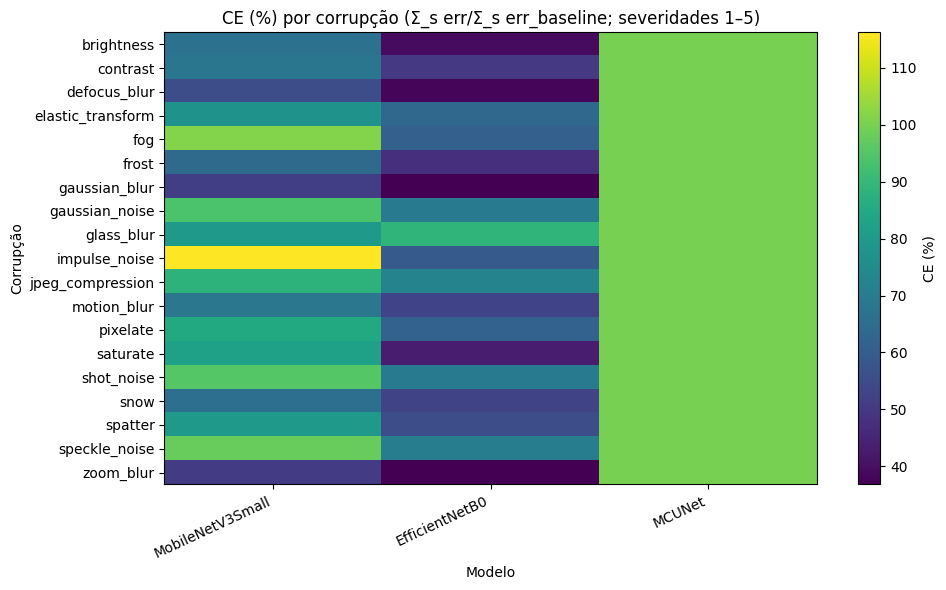

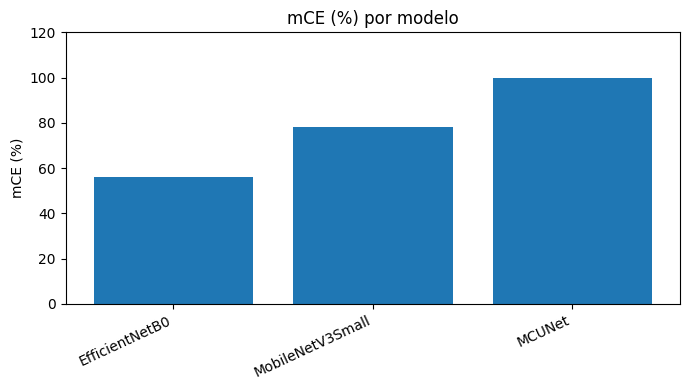

In [ ]:
# Tabela + plots: CE e mCE em porcentagem (%)
# - CE%: por corruption (CE=Σ_s err/Σ_s err_baseline, severidades 1–5)
# - mCE%: mean do CE% sobre corruptions
#
# Importante: esta cell lê os results direto do JSONL em `results/`.
try:
    import json
    from pathlib import Path

    import matplotlib.pyplot as plt

    RESULTS_DIR = ROOT / "results"

    # Prioridade: usar o caminho já definido pela cell de avaliação (se existir)
    if "CE_RESULTS_JSONL_PATH" in globals():
        JSONL_PATH = Path(CE_RESULTS_JSONL_PATH)
    else:
        # fallback: pega o primeiro *_ce_results.jsonl em results/
        matches = sorted(RESULTS_DIR.glob("*_ce_results.jsonl"))
        if not matches:
            raise FileNotFoundError("Could not find nenhum arquivo '*_ce_results.jsonl' em results/.")
        JSONL_PATH = matches[0]

    def _load_latest_jsonl(path: Path):
        latest = {}
        for line in path.read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if not line:
                continue
            r = json.loads(line)
            if isinstance(r, dict) and "model" in r and "corruption" in r:
                latest[(r["model"], r["corruption"])] = r
        return list(latest.values())

    ce_results = _load_latest_jsonl(JSONL_PATH)

    # Preferir a ordem de `models` se estiver disponível; senão inferir do JSONL
    if "models" in globals():
        model_names = [name for name, _, _ in models]
    else:
        model_names = sorted({r.get("model") for r in ce_results if r.get("model") is not None})

    # Preferir SELECTED (se existir); senão inferir do JSONL
    if "SELECTED" in globals():
        corruptions = list(SELECTED)
    else:
        corruptions = sorted({r["corruption"] for r in ce_results if "corruption" in r})

    # CE% (corruption x model)
    ce_pct = np.full((len(corruptions), len(model_names)), np.nan, dtype=float)
    for i, c in enumerate(corruptions):
        for j, name in enumerate(model_names):
            vals = [
                r["ce_mean_1_5"]
                for r in ce_results
                if r.get("model") == name and r.get("corruption") == c
            ]
            if len(vals) > 0:
                ce_pct[i, j] = float(np.nanmean(vals)) * 100.0

    # mCE% por model (mean sobre corruptions)
    mce_pct = np.nanmean(ce_pct, axis=0)

    def _fmt(x) -> str:
        if x is None:
            return "nan"
        x = float(x)
        return "nan" if np.isnan(x) else f"{x:.2f}"

    # ---- Tabela (texto) ----
    print("\n=== CE (%) por corruption ===")
    colw = max(12, max(len(n) for n in model_names) + 2)
    print(f"{'corruption':20s}" + "".join([f"{n:>{colw}s}" for n in model_names]))
    for i, c in enumerate(corruptions):
        row_vals = "".join([f"{_fmt(ce_pct[i, j]):>{colw}s}" for j in range(len(model_names))])
        print(f"{c:20s}" + row_vals)

    print("\n=== mCE (%) por model (mean sobre corruptions) ===")
    for name, val in sorted(zip(model_names, mce_pct), key=lambda t: (np.nan_to_num(t[1], nan=1e9))):
        print(f"{name:20s} {_fmt(float(val))}%")

    # ---- Plots (separados) ----

    # Heatmap CE%
    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    im = ax.imshow(ce_pct, aspect="auto", interpolation="nearest")
    ax.set_title("CE (%) por corruption (Σ_s err/Σ_s err_baseline; severidades 1–5)")
    ax.set_xlabel("Model")
    ax.set_ylabel("Corruption")
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=25, ha="right")
    ax.set_yticks(range(len(corruptions)))
    ax.set_yticklabels(corruptions)
    plt.colorbar(im, ax=ax, label="CE (%)")
    plt.tight_layout()
    plt.show()

    # Bar mCE% (ordenado melhor->pior; menor = melhor)
    order = np.argsort(np.nan_to_num(mce_pct, nan=1e9))
    ordered_names = [model_names[i] for i in order]
    ordered_vals = [float(mce_pct[i]) for i in order]

    plt.figure(figsize=(7, 4))
    ax = plt.gca()
    ax.bar(ordered_names, ordered_vals)
    ax.set_title("mCE (%) por model")
    ax.set_ylabel("mCE (%)")
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
    ax.set_ylim(0, max(120.0, float(np.nanmax(mce_pct)) * 1.15))
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Falha ao montar tabela/plots (CE%/mCE%):", e)


In [20]:
# Patch do JSONL: atualizar ce_mean_1_5 para razão das somas (sem recalcular inferências)
# Usa: acc_s1..acc_s5 de cada linha + baseline_acc salvo em JSON.

import json
from pathlib import Path

RESULTS_DIR = ROOT / "results"
JSONL_PATH = RESULTS_DIR / "cifar10c_baseline-MCUNet_ce_results.jsonl"
BASELINE_PATH = RESULTS_DIR / "cifar10c_baseline-MCUNet_baseline_acc.json"

SEVERITIES = [1, 2, 3, 4, 5]


def _err_from_acc(acc: float) -> float:
    return 1.0 - float(acc)


def _load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))


def _load_jsonl(path: Path):
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        rows.append(json.loads(line))
    return rows


baseline_acc = _load_json(BASELINE_PATH)  # dict: corruption -> {acc_s1..acc_s5, ...}
rows = _load_jsonl(JSONL_PATH)

updated = 0
skipped = 0

for r in rows:
    c = r.get("corruption")
    if not c or c not in baseline_acc:
        skipped += 1
        continue

    base = baseline_acc[c]

    # num = Σ_s err_model(s); den = Σ_s err_baseline(s)
    num = 0.0
    den = 0.0
    for s in SEVERITIES:
        am = r.get(f"acc_s{s}")
        ab = base.get(f"acc_s{s}")
        if am is None or ab is None:
            num = float("nan")
            den = float("nan")
            break
        num += _err_from_acc(am)
        den += _err_from_acc(ab)

    # guarda o valor antigo (se existir) e também recalcula mean-of-ratios a partir de ce_s*
    r.setdefault("ce_mean_1_5_old", r.get("ce_mean_1_5"))
    try:
        r["ce_mean_of_ratios_1_5"] = float(
            sum(float(r[f"ce_s{s}"]) for s in SEVERITIES) / len(SEVERITIES)
        )
    except Exception:
        pass

    r["ce_mean_1_5"] = float(num / den) if (den == den and den > 0) else float("nan")
    updated += 1

# Backup + escrita
bak = JSONL_PATH.with_suffix(JSONL_PATH.suffix + ".bak")
bak.write_text("\n".join(json.dumps(r, ensure_ascii=False) for r in rows) + "\n", encoding="utf-8")
JSONL_PATH.write_text("\n".join(json.dumps(r, ensure_ascii=False) for r in rows) + "\n", encoding="utf-8")

print(f"OK: atualizado ce_mean_1_5 em {updated} linhas; puladas {skipped}.")
print(f"Backup: {bak}")


OK: atualizado ce_mean_1_5 em 57 linhas; puladas 0.
Backup: results\cifar10c_baseline-MCUNet_ce_results.jsonl.bak


In [1]:
# =============================================================================
# Plot: Architecture Corruption Robustness (mCE e Relative mCE)
# =============================================================================
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ----- Dados de clean accuracy (obtidos na cell anterior) -----
CLEAN_ACC = {
    "MobileNetV3Small": 0.9044,
    "EfficientNetB0": 0.9461,
    "MCUNet": 0.8602,  # baseline
}
BASELINE_NAME = "MCUNet"

# ----- Load results do JSONL -----
RESULTS_DIR = ROOT / "results"
JSONL_PATH = RESULTS_DIR / "cifar10c_baseline-MCUNet_ce_results.jsonl"
BASELINE_ACC_PATH = RESULTS_DIR / "cifar10c_baseline-MCUNet_baseline_acc.json"

def _load_jsonl(path: Path):
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            rows.append(json.loads(line))
    return rows

def _load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))

ce_results = _load_jsonl(JSONL_PATH)
baseline_acc = _load_json(BASELINE_ACC_PATH)

# ----- Calcular mCE e Relative mCE por model -----
model_names = ["MobileNetV3Small", "EfficientNetB0", "MCUNet"]
corruptions_list = list(baseline_acc.keys())
SEVERITIES = [1, 2, 3, 4, 5]

def err_from_acc(acc):
    return 1.0 - float(acc)

# Organizar results por model
results_by_model = {name: {} for name in model_names}
for r in ce_results:
    model = r["model"]
    corruption = r["corruption"]
    results_by_model[model][corruption] = r

# Calcular CE e Relative CE por corruption
mce_data = {}
rel_mce_data = {}

for model in model_names:
    ce_list = []
    rel_ce_list = []
    clean_err = err_from_acc(CLEAN_ACC[model])
    
    for c in corruptions_list:
        if c not in results_by_model[model]:
            continue
            
        r = results_by_model[model][c]
        base = baseline_acc[c]
        
        # CE = Σ_s err_model(s) / Σ_s err_baseline(s)
        num_err = sum(err_from_acc(r[f"acc_s{s}"]) for s in SEVERITIES)
        den_err = sum(err_from_acc(base[f"acc_s{s}"]) for s in SEVERITIES)
        ce = num_err / den_err if den_err > 0 else float("nan")
        ce_list.append(ce)
        
        # Relative CE = Σ_s (err_model(s) - clean_err) / Σ_s (err_baseline(s) - clean_err_baseline)
        clean_err_baseline = err_from_acc(CLEAN_ACC[BASELINE_NAME])
        num_rel = sum(err_from_acc(r[f"acc_s{s}"]) - clean_err for s in SEVERITIES)
        den_rel = sum(err_from_acc(base[f"acc_s{s}"]) - clean_err_baseline for s in SEVERITIES)
        rel_ce = num_rel / den_rel if den_rel > 0 else float("nan")
        rel_ce_list.append(rel_ce)
    
    mce_data[model] = np.nanmean(ce_list) * 100  # em %
    rel_mce_data[model] = np.nanmean(rel_ce_list) * 100  # em %

# ----- Preparar dados para o plot -----
accuracy = np.array([CLEAN_ACC[m] * 100 for m in model_names])
mce = np.array([mce_data[m] for m in model_names])
relative_mce = np.array([rel_mce_data[m] for m in model_names])
labels = np.array(model_names)

print("=== Dados para o plot ===")
for i, name in enumerate(model_names):
    print(f"{name:20s} Acc={accuracy[i]:.2f}%  mCE={mce[i]:.2f}%  Rel.mCE={relative_mce[i]:.2f}%")



=== Dados para o plot ===
MobileNetV3Small     Acc=90.44%  mCE=78.32%  Rel.mCE=89.46%
EfficientNetB0       Acc=94.61%  mCE=56.31%  Rel.mCE=72.70%
MCUNet               Acc=86.02%  mCE=100.00%  Rel.mCE=100.00%



Plot salvo em: cifar10c_architecture_corruption_robustness.pdf


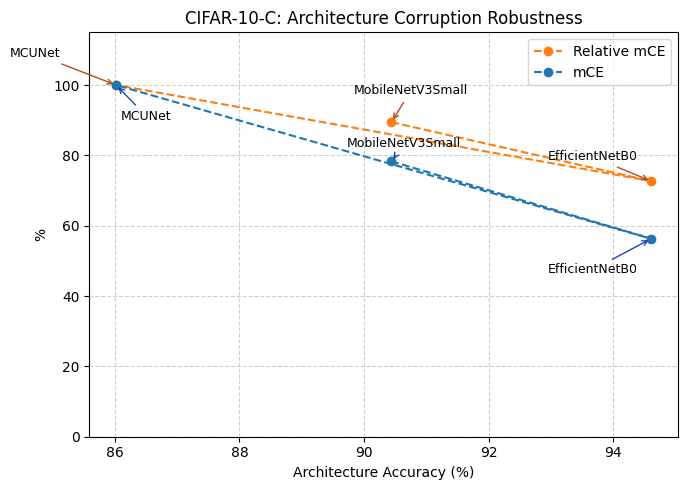

In [2]:
# ----- Gerar o plot -----
fig, ax = plt.subplots(figsize=(7, 5))

# Plotando com marcadores
ax.plot(accuracy, relative_mce, 'o--', color='#ff7f0e', label='Relative mCE', markersize=6)
ax.plot(accuracy, mce, 'o--', color='#1f77b4', label='mCE', markersize=6)

# Adicionar anotações com setas para mCE (azul)
for i, name in enumerate(model_names):
    # Anotação para mCE
    offset_mce = {
        "MCUNet": (40, -25),
        "MobileNetV3Small": (50, 10),
        "EfficientNetB0": (-10, -25),
    }
    ax.annotate(name, (accuracy[i], mce[i]), 
                textcoords="offset points", 
                xytext=offset_mce.get(name, (10, 10)), 
                ha='right', fontsize=9,
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#1f44b4'))

# Adicionar anotações para Relative mCE (laranja)
for i, name in enumerate(model_names):
    offset_rel = {
        "MCUNet": (-40, 20),
        "MobileNetV3Small": (55, 20),
        "EfficientNetB0": (-10, 15),
    }
    ax.annotate(name, (accuracy[i], relative_mce[i]), 
                textcoords="offset points", 
                xytext=offset_rel.get(name, (10, 10)), 
                ha='right', fontsize=9,
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#b44c1f'))

# Formatando o plot
ax.set_xlabel("Architecture Accuracy (%)")
ax.set_ylabel("%")
ax.set_title("CIFAR-10-C: Architecture Corruption Robustness")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# Ajustar limites do eixo y
y_max = max(max(mce), max(relative_mce)) * 1.15
ax.set_ylim(0, y_max)

plt.tight_layout()

# Salvar como PDF
plt.savefig(ROOT / "figures" / "cifar10c_architecture_corruption_robustness.pdf", format='pdf', bbox_inches='tight')
print("\nPlot salvo em: cifar10c_architecture_corruption_robustness.pdf")

plt.show()

In [2]:
# =============================================================================
# Gerar novos JSON/JSONL com baseline = MCUNet_Official
# Lê os dados de accuracy já existentes no JSONL (sem refazer inferências)
# =============================================================================
import json
import os
import numpy as np
from pathlib import Path

# ---- Configuração ----
NOVO_BASELINE = "MCUNet_Official"
SEVERITIES = [1, 2, 3, 4, 5]

RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Arquivo de entrada (JSONL antigo com todas as accuracies)
JSONL_ANTIGO = RESULTS_DIR / "cifar10c_baseline-MCUNet_ce_results.jsonl"

# Arquivos de saída (novos, com baseline = MCUNet_Official)
RUN_TAG_NOVO = f"cifar10c_baseline-{NOVO_BASELINE}".replace(" ", "_")
BASELINE_ACC_PATH_NOVO = RESULTS_DIR / f"{RUN_TAG_NOVO}_baseline_acc.json"
CE_JSONL_PATH_NOVO     = RESULTS_DIR / f"{RUN_TAG_NOVO}_ce_results.jsonl"

def err_from_acc(acc: float) -> float:
    return 1.0 - float(acc)

# ---- Load JSONL antigo ----
def _load_jsonl(path: Path):
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            try:
                rows.append(json.loads(line))
            except Exception:
                pass
    return rows

all_results = _load_jsonl(JSONL_ANTIGO)
print(f"Linhas lidas de {JSONL_ANTIGO.name}: {len(all_results)}")

# Desduplicar: pegar o último registro por (model, corruption)
results_by_key = {}
for r in all_results:
    key = (r["model"], r["corruption"])
    results_by_key[key] = r

model_names = sorted({r["model"] for r in results_by_key.values()})
corruptions_list = sorted({r["corruption"] for r in results_by_key.values()})

print(f"Models: {model_names}")
print(f"Corrupções: {len(corruptions_list)}")

if NOVO_BASELINE not in model_names:
    raise ValueError(f"'{NOVO_BASELINE}' não encontrado no JSONL! Models disponíveis: {model_names}")

# ---- 1) Montar baseline_acc JSON (accuracies do MCUNet_Official por corruption) ----
baseline_acc_novo = {}

for corr in corruptions_list:
    key = (NOVO_BASELINE, corr)
    if key not in results_by_key:
        print(f"  AVISO: {NOVO_BASELINE} não tem dados para '{corr}', pulando...")
        continue
    r = results_by_key[key]
    entry = {"corruption": corr}
    for s in SEVERITIES:
        entry[f"acc_s{s}"] = r[f"acc_s{s}"]
    entry["acc_mean_1_5"] = float(np.mean([r[f"acc_s{s}"] for s in SEVERITIES]))
    baseline_acc_novo[corr] = entry

# Salvar JSON do baseline
tmp = BASELINE_ACC_PATH_NOVO.with_suffix(".json.tmp")
tmp.write_text(json.dumps(baseline_acc_novo, ensure_ascii=False, indent=2), encoding="utf-8")
os.replace(tmp, BASELINE_ACC_PATH_NOVO)
print(f"\n✓ Baseline acc salvo em: {BASELINE_ACC_PATH_NOVO}")
print(f"  Corrupções no baseline: {len(baseline_acc_novo)}")

# ---- 2) Recalcular CE e salvar JSONL ----
# Limpa o arquivo de saída (cria do zero)
if CE_JSONL_PATH_NOVO.exists():
    # Backup antes de sobrescrever
    bak = CE_JSONL_PATH_NOVO.with_suffix(".jsonl.bak")
    CE_JSONL_PATH_NOVO.replace(bak)
    print(f"  Backup do JSONL anterior: {bak}")

with CE_JSONL_PATH_NOVO.open("w", encoding="utf-8") as f:
    for model in model_names:
        for corr in corruptions_list:
            key_model = (model, corr)
            if key_model not in results_by_key or corr not in baseline_acc_novo:
                continue

            r_model = results_by_key[key_model]
            r_base  = baseline_acc_novo[corr]

            row = {"model": model, "corruption": corr}
            num_err = 0.0
            den_err = 0.0

            for s in SEVERITIES:
                acc_ms = float(r_model[f"acc_s{s}"])
                acc_bs = float(r_base[f"acc_s{s}"])

                row[f"acc_s{s}"] = acc_ms
                ce_s = err_from_acc(acc_ms) / err_from_acc(acc_bs) if err_from_acc(acc_bs) > 0 else float("nan")
                row[f"ce_s{s}"] = ce_s

                num_err += err_from_acc(acc_ms)
                den_err += err_from_acc(acc_bs)

            row["acc_mean_1_5"] = float(np.mean([row[f"acc_s{s}"] for s in SEVERITIES]))
            row["ce_mean_of_ratios_1_5"] = float(np.nanmean([row[f"ce_s{s}"] for s in SEVERITIES]))
            row["ce_mean_1_5"] = float(num_err / den_err) if den_err > 0 else float("nan")

            f.write(json.dumps(row, ensure_ascii=False) + "\n")

    f.flush()
    os.fsync(f.fileno())

print(f"✓ CE results salvo em: {CE_JSONL_PATH_NOVO}")

# ---- 3) Resumo mCE ----
ce_novo = _load_jsonl(CE_JSONL_PATH_NOVO)

print(f"\n{'='*70}")
print(f"mCE RECALCULADO — baseline: {NOVO_BASELINE}")
print(f"{'='*70}")
print(f"{'Model':<20s} {'mCE (%)':<12s} {'Obs'}")
print("-" * 55)

for model in model_names:
    rows = [r for r in ce_novo if r["model"] == model]
    if not rows:
        continue
    mce = np.nanmean([r["ce_mean_1_5"] for r in rows]) * 100
    obs = " ← baseline (≈100%)" if model == NOVO_BASELINE else ""
    print(f"{model:<20s} {mce:<12.2f}{obs}")

print(f"\n{'='*70}")
print(f"Arquivos gerados:")
print(f"  {BASELINE_ACC_PATH_NOVO}")
print(f"  {CE_JSONL_PATH_NOVO}")
print(f"{'='*70}")

Linhas lidas de cifar10c_baseline-MCUNet_ce_results.jsonl: 76
Models: ['EfficientNetB0', 'MCUNet', 'MCUNet_Official', 'MobileNetV3Small']
Corrupções: 19

✓ Baseline acc salvo em: results\cifar10c_baseline-MCUNet_Official_baseline_acc.json
  Corrupções no baseline: 19
✓ CE results salvo em: results\cifar10c_baseline-MCUNet_Official_ce_results.jsonl

mCE RECALCULADO — baseline: MCUNet_Official
Model               mCE (%)      Obs
-------------------------------------------------------
EfficientNetB0       42.82       
MCUNet               76.36       
MCUNet_Official      100.00       ← baseline (≈100%)
MobileNetV3Small     58.95       

Arquivos gerados:
  results\cifar10c_baseline-MCUNet_Official_baseline_acc.json
  results\cifar10c_baseline-MCUNet_Official_ce_results.jsonl
